# NP2 — Aprendizado Supervisionado
## Decision Tree Regressor — Implementação From Scratch

**Disciplina:** Aprendizado Supervisionado  
**Professor:** Alex******  
**Dataset:** Car Sales Data (Kaggle)  
**Objetivo:** Prever o preço de venda de um automóvel com base em suas características.

---

# Contextualização
- Este projeto tem como objetivo a aplicação prática de Aprendizado de Máquina Supervisionado, abordando um problema de regressão, cujo propósito é prever o preço de veículos a partir de características técnicas e comerciais presentes em um dataset real obtido na plataforma Kaggle.
- O algoritmo escolhido foi a Árvore de Decisão para Regressão, implementada do zero, sem o uso de bibliotecas preditivas prontas. A árvore de decisão é um modelo não linear que realiza divisões sucessivas no espaço de atributos, buscando minimizar o erro dentro de cada partição.

# Tecnologias utilizadas: 
- Python: linguagem principal do projeto
- Jupyter Notebook: ambiente de desenvolvimento e relatório
- NumPy: cálculos matemáticos e operações matriciais
- Pandas: manipulação e tratamento do dataset
- Matplotlib: geração de gráficos para análise dos resultados

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Exploração Incial

In [61]:
df = pd.read_csv("car_sales_data.csv")

print(df.head())
print(df.info())

  Manufacturer       Model  Engine size Fuel type  Year of manufacture  \
0         Ford      Fiesta          1.0    Petrol                 2002   
1      Porsche  718 Cayman          4.0    Petrol                 2016   
2         Ford      Mondeo          1.6    Diesel                 2014   
3       Toyota        RAV4          1.8    Hybrid                 1988   
4           VW        Polo          1.0    Petrol                 2006   

   Mileage  Price  
0   127300   3074  
1    57850  49704  
2    39190  24072  
3   210814   1705  
4   127869   4101  
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  str    
 1   Model                50000 non-null  str    
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  str    
 4   Year of manufacture  50000 non-nu

In [62]:
numericas = df.select_dtypes(include=["number"]).columns.tolist()
categoricas = df.select_dtypes(exclude=["number"]).columns.tolist()

print(numericas)
print(categoricas)

['Engine size', 'Year of manufacture', 'Mileage', 'Price']
['Manufacturer', 'Model', 'Fuel type']


### Identificação do target

In [63]:
target = "Price"

### Identificação dos valores categóricos na coluna 'Manufacturer' para conversão em valores numéricos

In [64]:
df['Manufacturer'].unique()

<StringArray>
['Ford', 'Porsche', 'Toyota', 'VW', 'BMW']
Length: 5, dtype: str

### Identificação dos valores categóricos na coluna 'Model' para conversão em valores numéricos

In [65]:
df['Model'].unique()

<StringArray>
[    'Fiesta', '718 Cayman',     'Mondeo',       'RAV4',       'Polo',
      'Focus',      'Prius',       'Golf',         'Z4',      'Yaris',
        '911',     'Passat',         'M5',    'Cayenne',         'X3']
Length: 15, dtype: str

### Identificação dos valores categóricos na coluna 'Fuel type' para conversão em valores numéricos

In [66]:
df['Fuel type'].unique()

<StringArray>
['Petrol', 'Diesel', 'Hybrid']
Length: 3, dtype: str

### Criação de uma cópia do dataset para não modificar o original.
### Conversão simples das colunas categóricas em valores numéricos (atribui ID para cada valor), pois a árvore trabalha com valores numéricos

In [67]:
df_processed = df.copy()

for col in ["Manufacturer", "Model", "Fuel type"]:
    df_processed[col] = df_processed[col].astype("category").cat.codes + 1

# Valores convertidos para Manufactured

In [68]:
mapping_1 = {i: cat for i, cat in enumerate(df['Manufacturer'].astype('category').cat.categories, 1)}
print(mapping_1)

{1: 'BMW', 2: 'Ford', 3: 'Porsche', 4: 'Toyota', 5: 'VW'}


# Valores convertidos para Model

In [69]:
mapping_2 = {i: cat for i, cat in enumerate(df['Model'].astype('category').cat.categories, 1)}
print(mapping_2)

{1: '718 Cayman', 2: '911', 3: 'Cayenne', 4: 'Fiesta', 5: 'Focus', 6: 'Golf', 7: 'M5', 8: 'Mondeo', 9: 'Passat', 10: 'Polo', 11: 'Prius', 12: 'RAV4', 13: 'X3', 14: 'Yaris', 15: 'Z4'}


# Valores convertidos para Fuel type

In [70]:
mapping_3 = {i: cat for i, cat in enumerate(df['Fuel type'].astype('category').cat.categories, 1)}
print(mapping_3)

{1: 'Diesel', 2: 'Hybrid', 3: 'Petrol'}


# Separação entre X  e Y 
- X = (remove a coluna target, deixando apenas as features)
- y = (apenas a coluna target)

In [71]:
X = df_processed.drop(columns=[target]).values
y = df_processed[target].values

# Normalização Min-Max dos dados de entrada 
Coloca todos os valores da coluna na mesma escala (0 e 1) 
- Subtrai o menor valor de cada coluna 
- Calcula o range da coluna 
- Constante de segurança para evitar erros matemáticos de divisão por zero
- Evita dominância, os valores da coluna kilometragem são altos enquanto que na coluna Motor os valores são baixos, isso evita que o algoritmo entenda que km seja mais importante por serem maiores

In [72]:
def normalize(X):
    return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-8)

X = normalize(X)

### Divisão entre teino e teste

- seed = fixa um número garantindo que o embarralhamento seja sempre da mesma forma
- indices = cria uma lista do tamanho do dataset e embaralha aleatoriamente
- test_count = define a quantidade de dados para teste, o restante é destinao para treino
- test_idx e train_idx = separa dados de treino e de teste

In [73]:
def train_test_split(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    test_count = int(len(X) * test_size)

    test_idx = indices[:test_count]
    train_idx = indices[test_count:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

### Execução da função de treino e teste

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

## Cálculo do MSE

- Importante para qie a árvore decida onde fazer o corte nos dados - se MSE baixo significa que os preços estão próximos da média, dessa forma escolhe grupos com preços similares

In [75]:
def mse(y):
    return np.mean((y - np.mean(y)) ** 2)

# Algoritmo Regressor de Árvore de Decisão

- O algoritmo possui um limitador evitando que a árvore cresça demais e fique complexa (overfitting)
- número mínimo de amostras em um nó para ser dividido

### Função recursiva
- Verifica se deve parar de crescer (baseado na profundidade ou número de amostras).
- Se parar, ela calcula a média dos preços daquele grupo e retorna como resposta final.
- Se não parar, ela cria um "nó" com a melhor divisão encontrada e gera os ramos esquerdo e direito.

### Fit
- Inicia o processo de contrução da árvore começando na profundidade zero.

### Predict_row e Predict
- Pega um único carro e percorre a árvore até chegar em uma folha com o preço previsto.
- Aplica a função predict_row para todos os carros do seu conjunto de teste de uma vez.

In [ ]:
class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=5, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _mse(self, y):
        return np.mean((y - np.mean(y)) ** 2)

    def _best_split(self, X, y):
        best_mse = float("inf")
        best_feature = None
        best_threshold = None

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = X[:, feature] > threshold

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                left_y = y[left_mask]
                right_y = y[right_mask]

                weighted_mse = (
                    len(left_y) * self._mse(left_y) +
                    len(right_y) * self._mse(right_y)
                ) / len(y)

                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth):
        if (
            depth >= self.max_depth or
            len(y) < self.min_samples_split or
            self._mse(y) == 0
        ):
            return np.mean(y)

        feature, threshold = self._best_split(X, y)

        if feature is None:
            return np.mean(y)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        return {
            "feature": feature,
            "threshold": threshold,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1),
        }

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)

    def _predict_row(self, row, tree):
        if not isinstance(tree, dict):
            return tree

        if row[tree["feature"]] <= tree["threshold"]:
            return self._predict_row(row, tree["left"])
        else:
            return self._predict_row(row, tree["right"])

    def predict(self, X):
        return np.array([self._predict_row(row, self.tree) for row in X])


## Avaliação
- $R^2$ acima de 0.90 indica que o modelo atingiu 98% de precisão
- MAE indica que o modelo erra em média 1.304,40 para cima ou para baixo ente os valores
- MSE comparado a métrica anterior, indica que alguns poucos carros houvem outliers

In [80]:
model = DecisionTreeRegressorScratch(max_depth=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mae(y_test, y_pred))
print("MSE:", mse_metric(y_test, y_pred))
print("R² :", r2_score(y_test, y_pred))

MAE: 1304.9989986562061
MSE: 4421271.608164761
R² : 0.983707902011559


# Visualizações

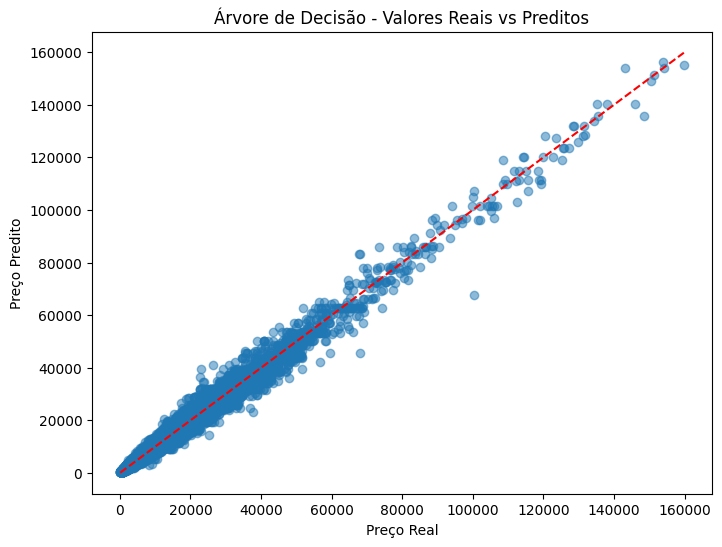

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Preço Real")
plt.ylabel("Preço Predito")
plt.title("Árvore de Decisão - Valores Reais vs Preditos")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")
plt.show()

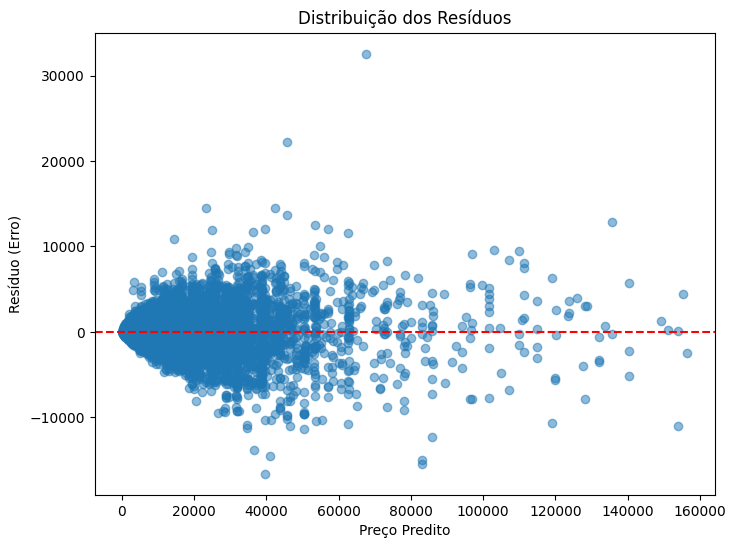

In [82]:
residuos = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuos, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Preço Predito")
plt.ylabel("Resíduo (Erro)")
plt.title("Distribuição dos Resíduos")
plt.show()

## Ajuste de Hiperparâmetros
O principal hiperparâmetro analisado neste projeto foi a profundidade máxima da árvore (max_depth), responsável por controlar a complexidade do modelo.

Inicialmente, foi testada uma profundidade menor (max_depth = 5), que apresentou bom desempenho geral. Em seguida, realizou-se um novo experimento aumentando a profundidade para max_depth = 10, permitindo que o modelo realizasse mais divisões e capturasse relações mais complexas entre os atributos.
Comparação entre profundidades




| Profundidade | MAE | MSE | R² |
|--------------|-----|-----|----|
| 5 | ≈ 3110 | ≈ 26.847.542 | ≈ 0,90 |
| **10** | **1304,99** | **4.421.271,61** | **0,9837** |

Observa-se que o aumento da profundidade resultou em uma redução expressiva dos erros e em um aumento significativo do coeficiente de determinação.



## Análise de Resultados

Com a profundidade ajustada para **10 níveis**, o modelo apresentou os seguintes resultados no conjunto de teste:

- **MAE (Erro Absoluto Médio):** 1304,99  
- **MSE (Erro Quadrático Médio):** 4.421.271,61  
- **R² (Coeficiente de Determinação):** 0,9837  

### Interpretação dos Resultados

- O valor de **MAE** indica que o erro médio absoluto das previsões foi reduzido para aproximadamente **1.305 unidades monetárias**, representando uma melhoria significativa em relação ao modelo com menor profundidade.
- A expressiva redução do **MSE** indica diminuição substancial de erros de grande magnitude.
- O valor de **R² ≈ 0,98** demonstra que o modelo é capaz de explicar cerca de **98% da variância do preço dos veículos**, caracterizando um desempenho excelente.

A análise visual por meio dos gráficos Real vs. Predito e de Resíduos reforça esses resultados, evidenciando boa aderência do modelo aos dados e ausência de padrões sistemáticos de erro relevantes



## Dificuldades e Limitações

Durante o desenvolvimento do projeto, algumas dificuldades e limitações foram identificadas:

- O aumento da profundidade da árvore eleva o **custo computacional** do treinamento.
- Árvores muito profundas podem apresentar **overfitting**, especialmente em cenários com ruído nos dados.
- A ausência de técnicas de **poda** torna o modelo mais sensível a variações no dataset.
- A codificação simples de variáveis categóricas pode limitar a capacidade de generalização do modelo



## Conclusão

A Árvore de Decisão para Regressão implementada neste projeto apresentou desempenho altamente satisfatório na tarefa de previsão de preços de veículos.

O ajuste do hiperparâmetro **profundidade máxima** teve impacto direto na performance do modelo. Enquanto profundidades menores apresentaram maior viés (*underfitting*), o aumento para **`max_depth = 10`** permitiu capturar padrões mais complexos do conjunto de dados, resultando em significativa redução dos erros e aumento do coeficiente de determinação.

Do ponto de vista do **trade-off viés–variância**, o modelo apresentou um equilíbrio adequado para o dataset analisado.